In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import pickle

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [4]:
df.shape

(7352, 563)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [6]:
df.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


In [7]:
df.isnull().sum()

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64

In [8]:
df.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)

In [9]:
X = df.drop(
    "Activity",
    axis=1
)

y = df["Activity"]

In [10]:
X.shape

(7352, 562)

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

In [13]:
X_pca.shape

(7352, 2)

In [14]:
pca.explained_variance_ratio_

array([0.5069245 , 0.06569275])

In [15]:
pca.explained_variance_ratio_.sum()

0.5726172463183775

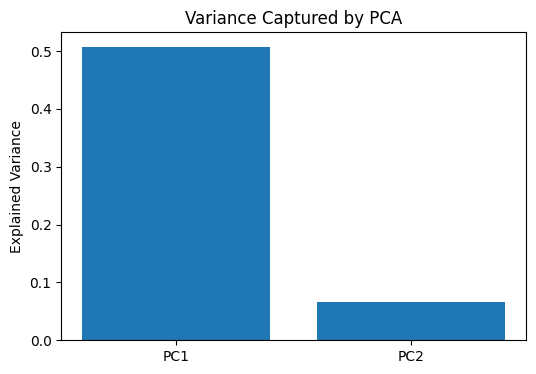

In [16]:
plt.figure(figsize=(6,4))

plt.bar(
    ["PC1","PC2"],
    pca.explained_variance_ratio_
)

plt.ylabel("Explained Variance")
plt.title("Variance Captured by PCA")

plt.show()

In [17]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)

pca_df["Activity"] = y.values

In [18]:
pca_df.head()

,PC1,PC2,Activity
0,-16.127876,2.165066,STANDING
1,-15.285529,1.400438,STANDING
2,-15.126334,2.486807,STANDING
3,-15.340192,3.929090,STANDING
4,-15.534146,4.611813,STANDING


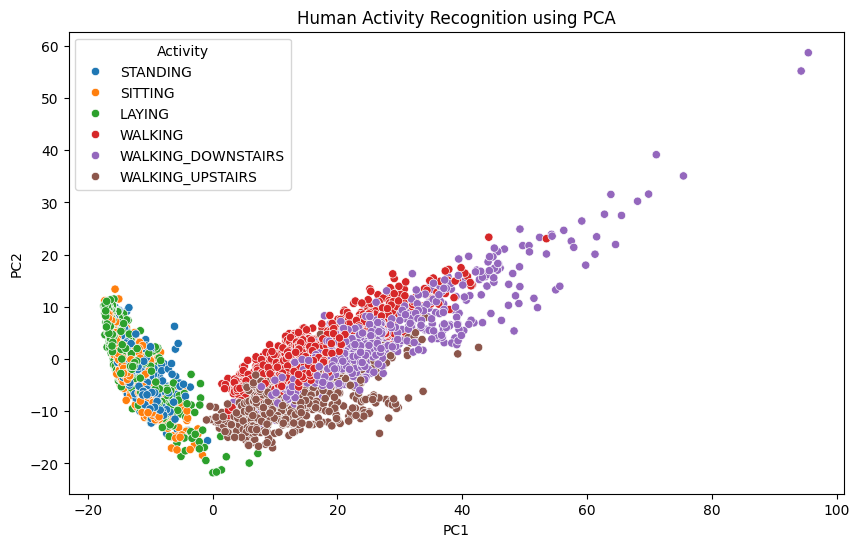

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Activity",
    palette="tab10"
)

plt.title(
    "Human Activity Recognition using PCA"
)

plt.show()

In [20]:
pca_full = PCA()

pca_full.fit(
    X_scaled
)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

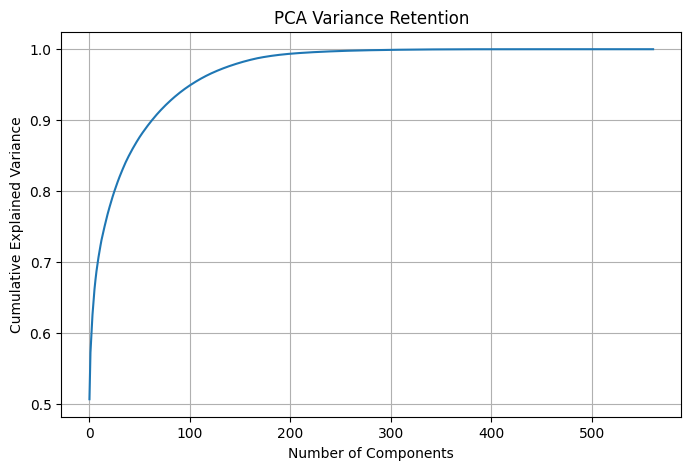

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    cumulative_variance
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Variance Retention"
)

plt.grid(True)

plt.show()

In [22]:
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Components for 95% Variance:",
    n_components_95
)

Components for 95% Variance: 102


In [23]:
pca_df.to_csv(
    "pca_data.csv",
    index=False
)

In [24]:
pickle.dump(
    pca,
    open(
        "pca_model.pkl",
        "wb"
    )
)

In [25]:
pickle.dump(
    scaler,
    open(
        "scaler.pkl",
        "wb"
    )
)

In [26]:
print(
    "Original Features:",
    X.shape[1]
)

print(
    "Reduced Features:",
    X_pca.shape[1]
)

Original Features: 562
Reduced Features: 2


In [27]:
pca.explained_variance_ratio_

array([0.5069245 , 0.06569275])

In [28]:
n_components_95

102

In [29]:
print("Original Features:", X.shape[1])
print("Components for 95% Variance:", n_components_95)

reduction = (
    (X.shape[1] - n_components_95)
    / X.shape[1]
) * 100

print(
    f"Dimensionality Reduction: {reduction:.2f}%"
)

Original Features: 562
Components for 95% Variance: 102
Dimensionality Reduction: 81.85%


In [30]:
pca_results = pd.DataFrame({
    "Metric": [
        "Original Features",
        "PCA Components",
        "Variance Retained (%)",
        "Components for 95% Variance"
    ],
    "Value": [
        X.shape[1],
        2,
        round(
            pca.explained_variance_ratio_.sum()*100,
            2
        ),
        n_components_95
    ]
})

pca_results

,Metric,Value
0,Original Features,562.00
1,PCA Components,2.00
2,Variance Retained (%),57.26
3,Components for 95% Variance,102.00
